In [1]:
# 고전 컴퓨터비전 실습 — ③ 분할(Segmentation) 사례1: 의료영상
# [Semantic(시맨틱) 방식] 장기·종양 영역을 "클래스" 단위로 분할
#
# 시맨틱 분할은 "이 픽셀이 배경인지/장기인지/종양인지" 클래스만 구분할 뿐,
# 같은 클래스 안에 종양이 여러 개 있어도 서로 구분하지 않고 모두 같은
# "종양" 라벨로 칠한다. (개별 종양을 따로 구분하는 것은 실습3의 인스턴스
# 분할에서 다룬다.)
#
# 실제 의료영상(CT/MRI) 데이터셋은 인터넷 다운로드·라이선스가 필요해 Colab에서
# 바로 실행하기 어려우므로, 이 실습에서는 CT 단면과 유사한 밝기 분포를 갖는
# 합성(synthetic) 영상을 코드로 직접 생성해 사용한다. 재현 가능하고(seed 고정)
# 다운로드가 전혀 필요 없다.
#
# 알고리즘: Multi-Otsu Thresholding — 영상 전체의 밝기(intensity) 히스토그램을
# 분석해, 클래스 수(배경/장기/종양=3개)만큼 자동으로 최적의 경계 밝기값을 찾아
# 픽셀을 분류하는 고전적인 비지도(unsupervised) 분할 기법이다.
#
# Clean Architecture 레이어:
#   [도메인 계층]      — 값 객체 + 추상 인터페이스. cv2/skimage 비의존.
#   [유스케이스 계층]   — SemanticSegmentationUseCase. 인터페이스만 주입받아 흐름 조립.
#   [인프라 계층]      — Multi-Otsu 기반 실제 구현체(분류/시각화 분리).
#   [구성 루트]        — Colab 셀: 합성 영상 생성, DI 조립, 시각화/저장.

## 셀 1: 환경 준비

In [2]:
# !pip install opencv-python-headless scikit-image matplotlib numpy --quiet
from __future__ import annotations

import numpy as np
import matplotlib
from matplotlib import font_manager as _font_manager
import glob as _glob
# 한글 폰트가 없는 환경(Colab 등)이면: !apt-get -qq install -y fonts-nanum && fc-cache -f
_candidates = _glob.glob("/usr/share/fonts/truetype/nanum/NanumGothic.ttf") + \
    _glob.glob("/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc") + \
    _glob.glob("/usr/share/fonts/**/NotoSansCJK*.ttc", recursive=True)
_korean_font_name = "sans-serif"
for _font_path in _candidates:
    try:
        _font_manager.fontManager.addfont(_font_path)
        _korean_font_name = _font_manager.FontProperties(fname=_font_path).get_name()
        break
    except Exception:
        continue
matplotlib.rcParams["font.family"] = _korean_font_name
matplotlib.rcParams["axes.unicode_minus"] = False

# ===== [도메인 계층 / Domain Layer] =====
# cv2/skimage를 전혀 모르는 순수 파이썬 계층. "시맨틱 분할이란 무엇을
# 입력받아 무엇을 돌려주는가"라는 계약만 정의한다.

from abc import ABC, abstractmethod
from dataclasses import dataclass, field


@dataclass(frozen=True)
class SemanticSegmentationResult:
    """시맨틱 분할 결과 값 객체. class_mask는 각 픽셀이 어떤 클래스에
    속하는지를 나타내는 정수 라벨 맵(원본과 같은 HxW 크기)이다."""
    original_image: np.ndarray            # 시각화용 원본(그레이스케일 또는 RGB)
    class_mask: np.ndarray                # HxW, 각 원소는 class_names의 key
    class_names: dict[int, str]           # {0: "배경", 1: "장기", 2: "종양"}
    class_colors: dict[int, tuple]        # 시각화용 RGB 색상

    def binary_mask_of(self, class_id: int) -> np.ndarray:
        """특정 클래스에 속하는 픽셀만 True인 이진 마스크. 인스턴스 분할
        실습(실습3)에서 이 메서드를 그대로 재사용해 "종양 클래스만" 뽑아낸다."""
        return self.class_mask == class_id


class SemanticSegmenter(ABC):
    """"영상을 받아 클래스별 라벨 맵을 돌려준다"는 계약만 정의한다. 알고리즘을
    Multi-Otsu가 아닌 다른 방식(색상 임계값, 딥러닝 등)으로 바꿔도 이 인터페이스만
    구현하면 유스케이스 코드를 전혀 수정할 필요가 없다 (OCP + DIP)."""

    @abstractmethod
    def segment(self, image: np.ndarray) -> SemanticSegmentationResult:
        ...


# ===== [유스케이스 계층 / Use Case Layer] =====
# 도메인 인터페이스만 생성자로 주입받아(DIP) 흐름을 조립한다.

class SemanticSegmentationUseCase:
    def __init__(self, segmenter: SemanticSegmenter):
        self._segmenter = segmenter

    def run(self, image: np.ndarray) -> SemanticSegmentationResult:
        return self._segmenter.segment(image)


# ===== [인프라/어댑터 계층 / Infrastructure Layer] =====
# skimage/cv2를 실제로 호출하는 유일한 계층. "분류 계산"과 "시각화"를
# 서로 다른 클래스로 분리한다(SRP).

import cv2
from skimage.filters import threshold_multiotsu


class MultiOtsuMedicalSegmenter(SemanticSegmenter):
    """Multi-Otsu 임계값으로 밝기 기준 3개 클래스(배경/장기/종양)를 분류하는
    어댑터. CT/MRI 영상은 흔히 "배경이 가장 어둡고, 종양(조영 증강)이
    가장 밝다"는 밝기 순서를 가정할 수 있어 임계값 기반 분류가 잘 통한다."""

    def __init__(self, n_classes: int = 3, blur_ksize: int = 3):
        self._n_classes = n_classes
        self._blur_ksize = blur_ksize

    def segment(self, image: np.ndarray) -> SemanticSegmentationResult:
        gray = image if image.ndim == 2 else cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        denoised = cv2.medianBlur(gray, self._blur_ksize)

        thresholds = threshold_multiotsu(denoised, classes=self._n_classes)
        class_mask = np.digitize(denoised, bins=thresholds).astype(np.int32)

        return SemanticSegmentationResult(
            original_image=gray,
            class_mask=class_mask,
            class_names={0: "배경", 1: "장기", 2: "종양"},
            class_colors={0: (20, 20, 30), 1: (70, 140, 200), 2: (235, 70, 70)},
        )


class SemanticSegmentationVisualizer:
    """시각화 전담 클래스(SRP). 클래스 라벨 맵을 색상으로 칠해 원본과
    나란히 보여주고 파일로 저장한다. 계산 로직(분류)과는 완전히 독립적이다."""

    def __init__(self, title: str):
        self._title = title

    def _colorize(self, result: SemanticSegmentationResult) -> np.ndarray:
        h, w = result.class_mask.shape
        colored = np.zeros((h, w, 3), dtype=np.uint8)
        for class_id, color in result.class_colors.items():
            colored[result.class_mask == class_id] = color
        return colored

    def save_result(self, result: SemanticSegmentationResult, out_path: str) -> None:
        import matplotlib.pyplot as plt
        import matplotlib.patches as mpatches

        colored = self._colorize(result)

        fig, axes = plt.subplots(1, 2, figsize=(12, 6))
        fig.suptitle(self._title, fontsize=14, fontweight="bold")

        axes[0].imshow(result.original_image, cmap="gray")
        axes[0].set_title("1. 원본 (합성 CT 단면)")
        axes[0].axis("off")

        axes[1].imshow(colored)
        axes[1].set_title("2. Semantic 분할 결과 (클래스별 색상)")
        axes[1].axis("off")
        legend_patches = [
            mpatches.Patch(color=np.array(c) / 255, label=f"{result.class_names[cid]}")
            for cid, c in result.class_colors.items()
        ]
        axes[1].legend(handles=legend_patches, loc="upper right", fontsize=10, framealpha=0.9)

        plt.tight_layout()
        plt.savefig(out_path, dpi=120, bbox_inches="tight")
        plt.show()
        print(f"저장 완료: {out_path}")

        for class_id, name in result.class_names.items():
            pixel_count = int(np.count_nonzero(result.class_mask == class_id))
            print(f"  - {name}(클래스 {class_id}): {pixel_count:,}픽셀")


# ===== [구성 루트 / Composition Root — Colab 실행 코드] =====

## 셀 2: 합성 CT 단면 영상 생성 (재현 가능하도록 seed 고정)

In [3]:
def make_synthetic_ct_slice(size: int = 256, seed: int = 42) -> np.ndarray:
    """배경(어두움) 위에 타원형 "장기"(중간 밝기)를 그리고, 그 안에 작은
    "종양" 2개(밝음)를 배치한 합성 CT 단면을 생성한다."""
    rng = np.random.default_rng(seed)
    canvas = np.full((size, size), 25, dtype=np.float64)  # 배경

    # 장기(타원)
    yy, xx = np.ogrid[:size, :size]
    organ_mask = ((xx - 128) / 85) ** 2 + ((yy - 128) / 100) ** 2 <= 1
    canvas[organ_mask] = 120

    # 종양 2개 (장기 내부의 작은 원형 덩어리)
    tumor_centers = [(95, 110), (160, 145)]
    tumor_radii = [18, 14]
    for (cy, cx), r in zip(tumor_centers, tumor_radii):
        tumor_mask = (xx - cx) ** 2 + (yy - cy) ** 2 <= r ** 2
        canvas[tumor_mask] = 215

    # 가우시안 잡음 추가(실제 영상처럼)
    noise = rng.normal(0, 6, size=canvas.shape)
    canvas = np.clip(canvas + noise, 0, 255).astype(np.uint8)
    return canvas


ct_image = make_synthetic_ct_slice(size=256, seed=42)
print("합성 CT 영상 크기:", ct_image.shape)

합성 CT 영상 크기: (256, 256)


## 셀 3: 구체 어댑터 생성 + 의존성 주입(DIP)

In [4]:
segmenter: SemanticSegmenter = MultiOtsuMedicalSegmenter(n_classes=3, blur_ksize=3)
use_case = SemanticSegmentationUseCase(segmenter=segmenter)

## 셀 4: 실행

In [5]:
result = use_case.run(ct_image)
print("검출된 클래스:", result.class_names)

검출된 클래스: {0: '배경', 1: '장기', 2: '종양'}


## 셀 5: 결과 시각화 및 저장

/tmp/ipykernel_2752/3822788790.py:135: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2752/3822788790.py:135: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2752/3822788790.py:135: UserWarning: Glyph 54633 (\N{HANGUL SYLLABLE HAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2752/3822788790.py:135: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2752/3822788790.py:135: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2752/3822788790.py:135: UserWarning: Glyph 47732 (\N{HANGUL SYLLABLE MYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2752/3822788790.py:135: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
 

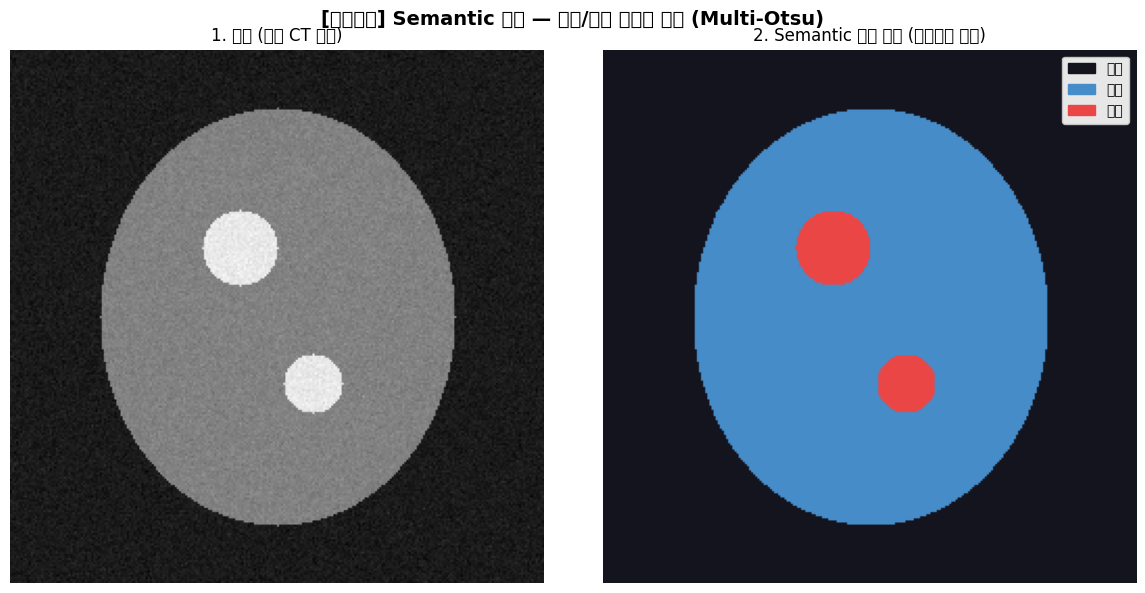

저장 완료: medical_semantic_result.png
  - 배경(클래스 0): 38,848픽셀
  - 장기(클래스 1): 25,072픽셀
  - 종양(클래스 2): 1,616픽셀


In [7]:
visualizer = SemanticSegmentationVisualizer(
    title="[의료영상] Semantic 분할 — 장기/종양 클래스 분류 (Multi-Otsu)"
)
visualizer.save_result(result, "medical_semantic_result.png")

## 셀 6: (참고) 시맨틱 분할의 한계 확인 — 종양이 2개지만 모두 같은

In [8]:
# 라벨(클래스 2)로 칠해져 "몇 개인지"는 알 수 없다. 개별 개수를 구분하려면
# 실습3(인스턴스 분할)처럼 connected components로 한 번 더 나눠야 한다.
tumor_binary = result.binary_mask_of(class_id=2)
n_components, _ = cv2.connectedComponents(tumor_binary.astype(np.uint8))
print(f"\n참고: 시맨틱 마스크만으로는 '종양'이라는 클래스 1개만 보이지만,")
print(f"실제로는 서로 떨어진 덩어리가 {n_components - 1}개 있습니다 "
      f"(인스턴스 분할 실습에서 이를 구분합니다).")


참고: 시맨틱 마스크만으로는 '종양'이라는 클래스 1개만 보이지만,
실제로는 서로 떨어진 덩어리가 2개 있습니다 (인스턴스 분할 실습에서 이를 구분합니다).
